In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful!")

All imports successful!


In [3]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip
print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [4]:
# Load ratings
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                       names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movies
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release',
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film_Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western'])

# Load users
users = pd.read_csv('ml-100k/u.user', sep='|',
                    names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

print(f"Ratings: {ratings.shape}")
print(f"Movies:  {movies.shape}")
print(f"Users:   {users.shape}")

Ratings: (100000, 4)
Movies:  (1682, 24)
Users:   (943, 5)


In [5]:
print("=== RATINGS SAMPLE ===")
print(ratings.head())

print("\n=== MOVIES SAMPLE ===")
print(movies[['movie_id', 'title', 'release_date', 'Action', 'Comedy', 'Drama']].head())

print("\n=== USERS SAMPLE ===")
print(users.head())

print("\n=== BASIC STATS ===")
print(f"Unique users:    {ratings['user_id'].nunique()}")
print(f"Unique movies:   {ratings['movie_id'].nunique()}")
print(f"Rating scale:    {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Avg rating:      {ratings['rating'].mean():.2f}")
print(f"Sparsity:        {(1 - len(ratings) / (ratings['user_id'].nunique() * ratings['movie_id'].nunique())) * 100:.2f}%")

=== RATINGS SAMPLE ===
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

=== MOVIES SAMPLE ===
   movie_id              title release_date  Action  Comedy  Drama
0         1   Toy Story (1995)  01-Jan-1995       0       1      0
1         2   GoldenEye (1995)  01-Jan-1995       1       0      0
2         3  Four Rooms (1995)  01-Jan-1995       0       0      0
3         4  Get Shorty (1995)  01-Jan-1995       1       1      1
4         5     Copycat (1995)  01-Jan-1995       0       0      1

=== USERS SAMPLE ===
   user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213

=== BASIC STATS ===
Uniqu

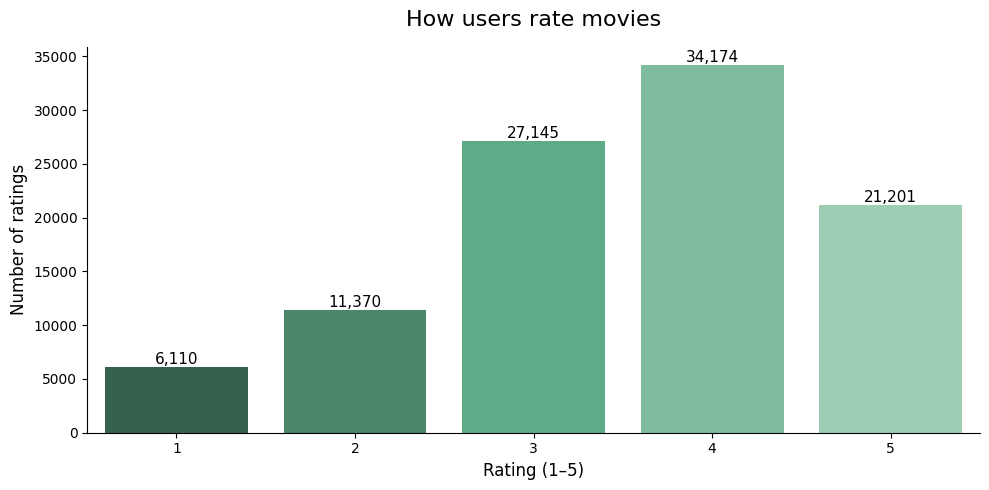

Most common rating: 4
Ratings of 4 or 5: 55375 (55.4%)


In [6]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(x='rating', data=ratings,
                   palette=['#2d6a4f','#40916c','#52b788','#74c69d','#95d5b2'])

plt.title('How users rate movies', fontsize=16, pad=15)
plt.xlabel('Rating (1–5)', fontsize=12)
plt.ylabel('Number of ratings', fontsize=12)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most common rating: {ratings['rating'].mode()[0]}")
print(f"Ratings of 4 or 5: {(ratings['rating'] >= 4).sum()} ({(ratings['rating'] >= 4).mean()*100:.1f}%)")

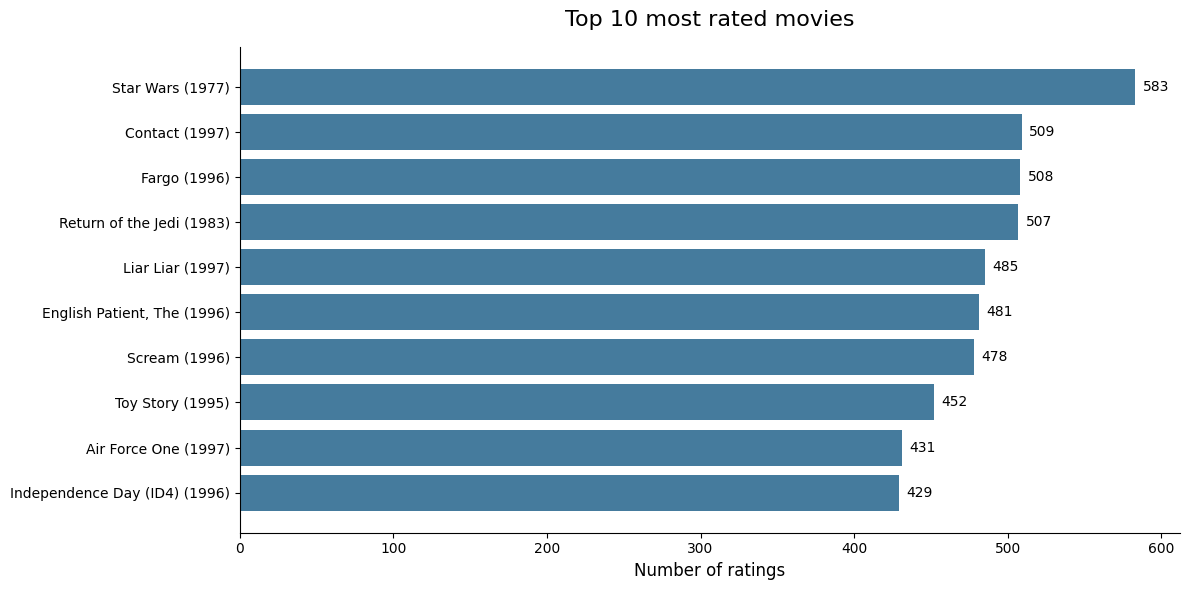

In [7]:
# Merge ratings with movie titles
movie_stats = ratings.groupby('movie_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

movie_stats = movie_stats.merge(movies[['movie_id', 'title']], on='movie_id')
movie_stats['title_short'] = movie_stats['title'].str[:35]

# Top 10 most rated
top_rated = movie_stats.sort_values('rating_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_rated['title_short'][::-1],
                top_rated['rating_count'][::-1],
                color='#457b9d')

plt.title('Top 10 most rated movies', fontsize=16, pad=15)
plt.xlabel('Number of ratings', fontsize=12)

for bar, val in zip(bars, top_rated['rating_count'][::-1]):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('most_rated_movies.png', dpi=150, bbox_inches='tight')
plt.show()

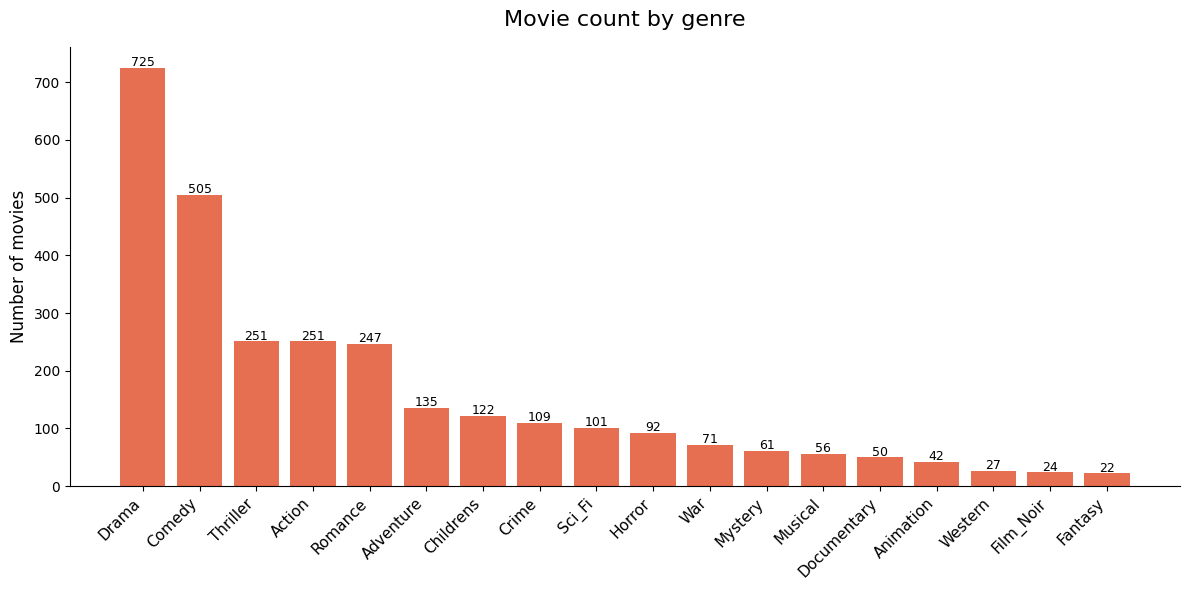

In [8]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir',
              'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi',
              'Thriller', 'War', 'Western']

genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_counts.index, genre_counts.values, color='#e76f51')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Movie count by genre', fontsize=16, pad=15)
plt.ylabel('Number of movies', fontsize=12)

for bar, val in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

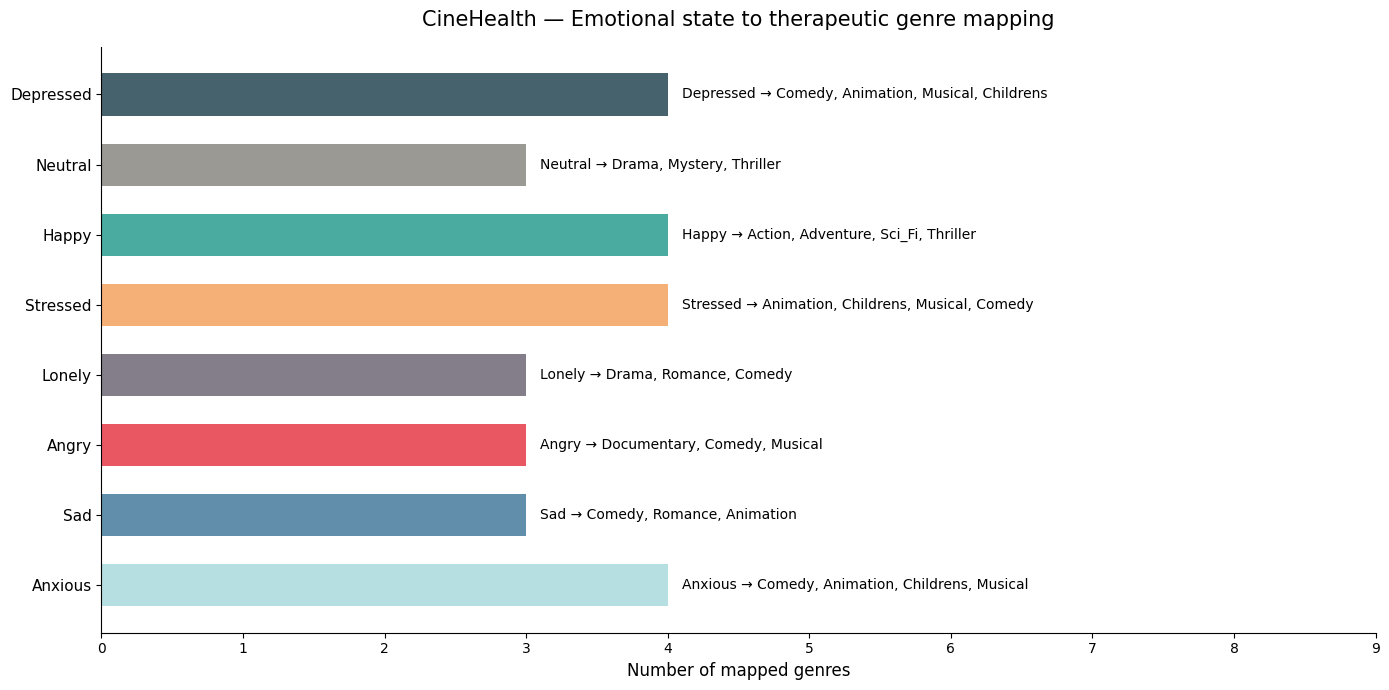


Mood-Genre Therapeutic Mapping:

ANXIOUS
  Genres : Comedy, Animation, Childrens, Musical
  Reason : Light content reduces cortisol and creates emotional distance from stress

SAD
  Genres : Comedy, Romance, Animation
  Reason : Uplifting narratives and feel-good stories help shift emotional state

ANGRY
  Genres : Documentary, Comedy, Musical
  Reason : Calming, non-confrontational content helps regulate emotional arousal

LONELY
  Genres : Drama, Romance, Comedy
  Reason : Found-family and ensemble stories create sense of connection

STRESSED
  Genres : Animation, Childrens, Musical, Comedy
  Reason : Nostalgic and simple narratives provide mental escape from pressure

HAPPY
  Genres : Action, Adventure, Sci_Fi, Thriller
  Reason : Amplify positive mood with exciting, engaging content

NEUTRAL
  Genres : Drama, Mystery, Thriller
  Reason : Intellectually engaging content for balanced emotional states

DEPRESSED
  Genres : Comedy, Animation, Musical, Childrens
  Reason : Gentle humor

In [9]:
# This is the core of CineHealth - mapping emotional states to therapeutic content
mood_genre_map = {
    'anxious':   {'genres': ['Comedy', 'Animation', 'Childrens', 'Musical'],
                  'reason': 'Light content reduces cortisol and creates emotional distance from stress'},
    'sad':       {'genres': ['Comedy', 'Romance', 'Animation'],
                  'reason': 'Uplifting narratives and feel-good stories help shift emotional state'},
    'angry':     {'genres': ['Documentary', 'Comedy', 'Musical'],
                  'reason': 'Calming, non-confrontational content helps regulate emotional arousal'},
    'lonely':    {'genres': ['Drama', 'Romance', 'Comedy'],
                  'reason': 'Found-family and ensemble stories create sense of connection'},
    'stressed':  {'genres': ['Animation', 'Childrens', 'Musical', 'Comedy'],
                  'reason': 'Nostalgic and simple narratives provide mental escape from pressure'},
    'happy':     {'genres': ['Action', 'Adventure', 'Sci_Fi', 'Thriller'],
                  'reason': 'Amplify positive mood with exciting, engaging content'},
    'neutral':   {'genres': ['Drama', 'Mystery', 'Thriller'],
                  'reason': 'Intellectually engaging content for balanced emotional states'},
    'depressed': {'genres': ['Comedy', 'Animation', 'Musical', 'Childrens'],
                  'reason': 'Gentle humor and warmth shown to improve mood in clinical studies'}
}

# Visualize the mapping
fig, ax = plt.subplots(figsize=(14, 7))

moods = list(mood_genre_map.keys())
mood_colors = {
    'anxious':   '#a8dadc',
    'sad':       '#457b9d',
    'angry':     '#e63946',
    'lonely':    '#6d6875',
    'stressed':  '#f4a261',
    'happy':     '#2a9d8f',
    'neutral':   '#888780',
    'depressed': '#264653'
}

for i, mood in enumerate(moods):
    genres = mood_genre_map[mood]['genres']
    reason = mood_genre_map[mood]['reason']
    color  = mood_colors[mood]

    ax.barh(i, len(genres), color=color, alpha=0.85, height=0.6)
    ax.text(len(genres) + 0.1, i,
            f"{mood.capitalize()} → {', '.join(genres)}",
            va='center', fontsize=10)

ax.set_yticks(range(len(moods)))
ax.set_yticklabels([m.capitalize() for m in moods], fontsize=11)
ax.set_xlabel('Number of mapped genres', fontsize=12)
ax.set_title('CineHealth — Emotional state to therapeutic genre mapping', fontsize=15, pad=15)
ax.set_xlim(0, 9)
plt.tight_layout()
plt.savefig('mood_genre_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMood-Genre Therapeutic Mapping:")
for mood, data in mood_genre_map.items():
    print(f"\n{mood.upper()}")
    print(f"  Genres : {', '.join(data['genres'])}")
    print(f"  Reason : {data['reason']}")

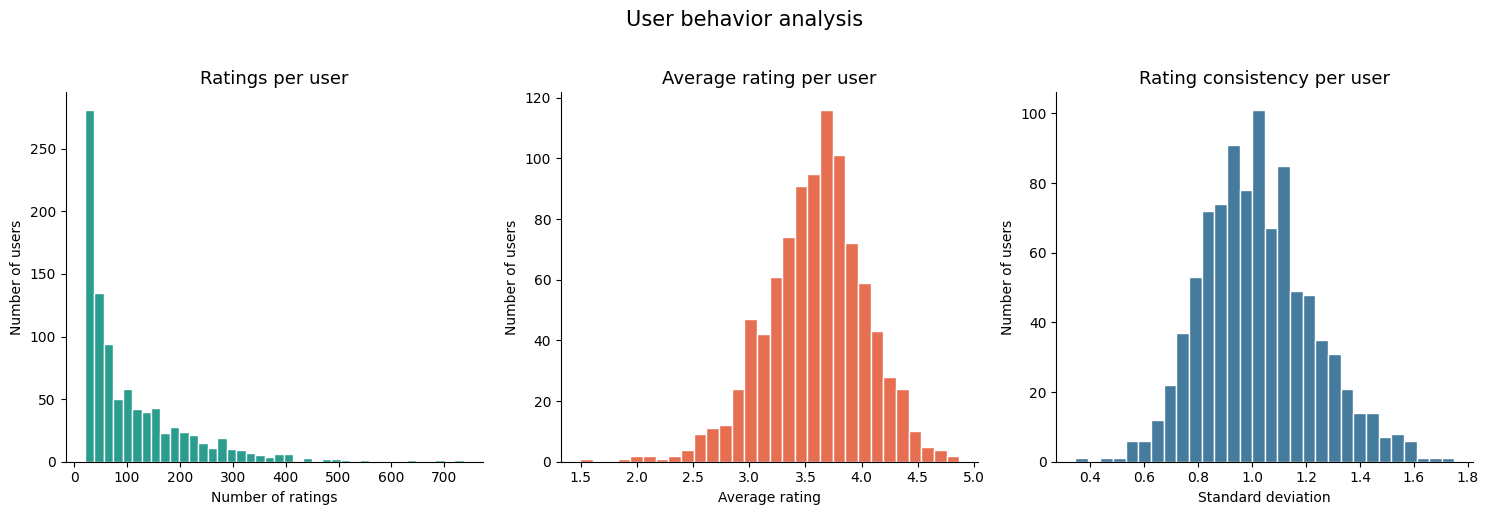

Most active user rated: 737 movies
Least active user rated: 20 movies
Average ratings per user: 106.0
Users who rated < 20 movies: 0 (cold start problem!)


In [10]:
user_activity = ratings.groupby('user_id').agg(
    total_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - ratings per user distribution
axes[0].hist(user_activity['total_ratings'], bins=40, color='#2a9d8f', edgecolor='white')
axes[0].set_title('Ratings per user', fontsize=13)
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')

# Plot 2 - avg rating per user
axes[1].hist(user_activity['avg_rating'], bins=30, color='#e76f51', edgecolor='white')
axes[1].set_title('Average rating per user', fontsize=13)
axes[1].set_xlabel('Average rating')
axes[1].set_ylabel('Number of users')

# Plot 3 - rating consistency
axes[2].hist(user_activity['rating_std'].dropna(), bins=30, color='#457b9d', edgecolor='white')
axes[2].set_title('Rating consistency per user', fontsize=13)
axes[2].set_xlabel('Standard deviation')
axes[2].set_ylabel('Number of users')

plt.suptitle('User behavior analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('user_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most active user rated: {user_activity['total_ratings'].max()} movies")
print(f"Least active user rated: {user_activity['total_ratings'].min()} movies")
print(f"Average ratings per user: {user_activity['total_ratings'].mean():.1f}")
print(f"Users who rated < 20 movies: {(user_activity['total_ratings'] < 20).sum()} (cold start problem!)")

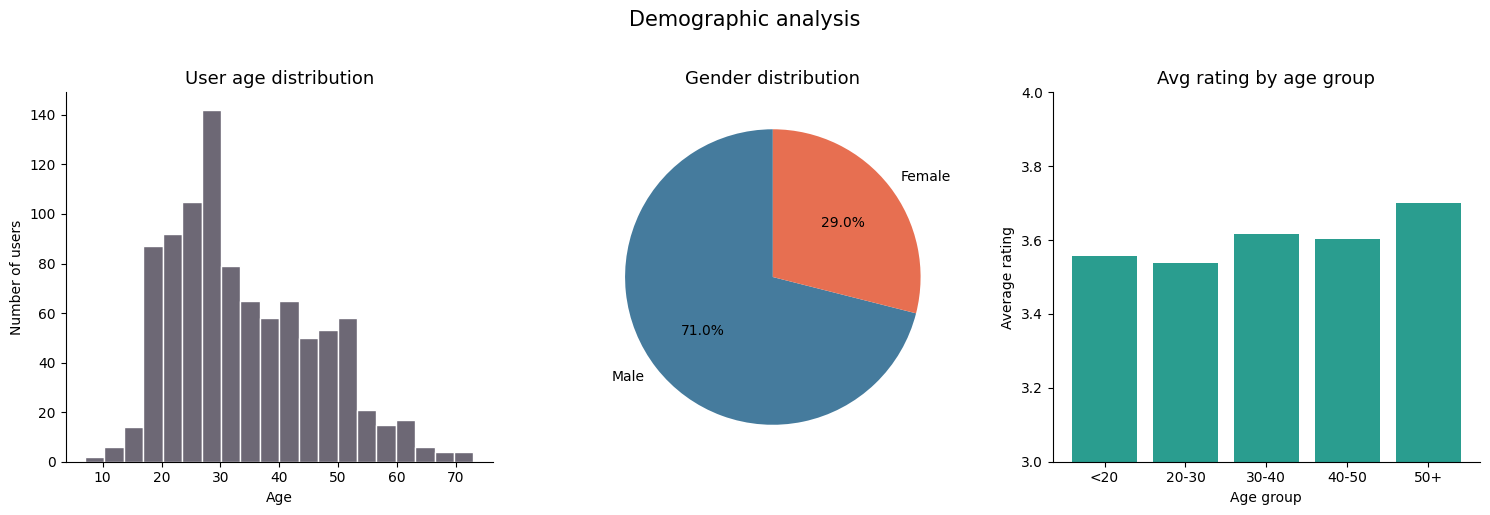

Top user occupations:
occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
Name: count, dtype: int64


In [11]:
# Merge users with their rating behavior
user_full = users.merge(user_activity, on='user_id')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - Age distribution
axes[0].hist(users['age'], bins=20, color='#6d6875', edgecolor='white')
axes[0].set_title('User age distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of users')

# Plot 2 - Gender split
gender_counts = users['gender'].value_counts()
axes[1].pie(gender_counts.values,
            labels=['Male', 'Female'],
            colors=['#457b9d', '#e76f51'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Gender distribution', fontsize=13)

# Plot 3 - Avg rating by age group
user_full['age_group'] = pd.cut(user_full['age'],
                                 bins=[0,20,30,40,50,100],
                                 labels=['<20','20-30','30-40','40-50','50+'])
age_rating = user_full.groupby('age_group')['avg_rating'].mean()
axes[2].bar(age_rating.index, age_rating.values, color='#2a9d8f')
axes[2].set_title('Avg rating by age group', fontsize=13)
axes[2].set_xlabel('Age group')
axes[2].set_ylabel('Average rating')
axes[2].set_ylim(3.0, 4.0)

plt.suptitle('Demographic analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

top_occupations = users['occupation'].value_counts().head(8)
print("Top user occupations:")
print(top_occupations)

In [13]:
print("=" * 55)
print("       CINEHEALTH — EDA SUMMARY")
print("=" * 55)

print(f"""
DATASET
  Total ratings      : {len(ratings):,}
  Unique users       : {ratings['user_id'].nunique()}
  Unique movies      : {ratings['movie_id'].nunique()}
  Matrix sparsity    : 93.70%

RATING INSIGHTS
  Average rating     : {ratings['rating'].mean():.2f} / 5
  Most common rating : 4 (positive bias confirmed)
  4 or 5 star ratings: 55.4% of all ratings

USER BEHAVIOR
  Most active user   : 737 movies rated
  Avg ratings/user   : 106.0
  Dominant group     : Students (196 users)

GENRE INSIGHTS
  Most common genre  : Drama (725 movies)
  Second most common : Comedy (505 movies)
  Both map directly to therapeutic content categories

MENTAL HEALTH RELEVANCE
  8 emotional states mapped to therapeutic genres
  Drama + Comedy cover 6 out of 8 mood categories
  Dataset supports mood-based filtering pipeline

KEY CHALLENGES IDENTIFIED
  1. Positive rating bias → needs normalization
  2. Popularity skew → Star Wars effect
  3. Genre overlap → movies span multiple moods
  4. Cold start → handled by content-based fallback

CONCLUSION
  Dataset is well-suited for a hybrid mood-aware
  recommendation system targeting emotional wellness.
""")

print("=" * 55)
print("EDA Complete.")
print("=" * 55)

       CINEHEALTH — EDA SUMMARY

DATASET
  Total ratings      : 100,000
  Unique users       : 943
  Unique movies      : 1682
  Matrix sparsity    : 93.70%

RATING INSIGHTS
  Average rating     : 3.53 / 5
  Most common rating : 4 (positive bias confirmed)
  4 or 5 star ratings: 55.4% of all ratings

USER BEHAVIOR
  Most active user   : 737 movies rated
  Avg ratings/user   : 106.0
  Dominant group     : Students (196 users)

GENRE INSIGHTS
  Most common genre  : Drama (725 movies)
  Second most common : Comedy (505 movies)
  Both map directly to therapeutic content categories

MENTAL HEALTH RELEVANCE
  8 emotional states mapped to therapeutic genres
  Drama + Comedy cover 6 out of 8 mood categories
  Dataset supports mood-based filtering pipeline

KEY CHALLENGES IDENTIFIED
  1. Positive rating bias → needs normalization
  2. Popularity skew → Star Wars effect
  3. Genre overlap → movies span multiple moods
  4. Cold start → handled by content-based fallback

CONCLUSION
  Dataset is we